# Yang-Style Fixation-Gated Circular Working Memory

This notebook is a thin walkthrough for the current canonical dissertation model. It loads the existing package code and saved artifacts rather than duplicating model logic in notebook cells.

By default, cells inspect cached metrics and figures. Set the `RUN_*` flags to `True` only when you want to regenerate artifacts from the checkpoint.

In [2]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
import yaml
from IPython.display import HTML, Image, display

def find_repo(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "src" / "wm_rnn").exists():
            return path
    raise RuntimeError(
        f"Could not find working-memory-rnn root (src/wm_rnn) from {start}"
    )


REPO = find_repo(Path.cwd().resolve())
sys.path.insert(0, str(REPO / "src"))

CONFIG_PATH = REPO / "configs" / "yang_fixation_circular_working_memory.yaml"
OUTPUT_DIR = REPO / "outputs" / "yang_fixation_circular_working_memory"
RUN_NAME = "yang_fixation_circular_working_memory"
CHECKPOINT = OUTPUT_DIR / "checkpoints" / f"{RUN_NAME}.pt"

RUN_EVALUATION = False
RUN_DELAY_SWEEP = False
RUN_PCA = False
RUN_DECODER = False

print("repo:", REPO)
print("python:", sys.executable)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("checkpoint exists:", CHECKPOINT.exists())

repo: C:\Users\Bob Rice\Documents\Obsidian Vault\Dissertation\working-memory-rnn
python: c:\Users\Bob Rice\Documents\Obsidian Vault\Dissertation\working-memory-rnn\.venv\Scripts\python.exe
torch: 2.10.0+cu126
cuda available: True
checkpoint exists: True


## Configuration

The active config defines a tuned circular task with fixation input/output, randomized pre-cue/cue/delay timing, training noise, weighted loss, and gradient clipping.

In [3]:
from wm_rnn.config import load_config

cfg = load_config(CONFIG_PATH)
print(yaml.safe_dump(cfg, sort_keys=False))

task:
  task_type: tuned
  n_classes: 4
  cue_steps: 20
  delay_steps: 20
  response_steps: 25
  batch_size: 64
  seed: 20260713
  n_tuned_units: 32
  tuning_kappa: 8.0
  pre_cue_steps: 25
  pre_cue_steps_choices:
  - 15
  - 25
  - 35
  cue_steps_choices:
  - 10
  - 20
  - 30
  delay_steps_choices:
  - 10
  - 20
  - 40
  - 80
  fixation_gated: true
model:
  hidden_size: 64
  dt: 20.0
  tau: 100.0
  activation: tanh
  recurrent_noise_std: 0.05
training:
  steps: 4000
  learning_rate: 0.001
  log_every: 100
  device: auto
  yang_weighted_loss: true
  ignore_initial_steps: 5
  response_transition_steps: 5
  response_weight: 5.0
  fixation_weight: 2.0
  input_noise_std: 0.01
  gradient_clip_value: 1.0
evaluation:
  batches: 20
analysis:
  n_components: 2
  n_trials: 64
paths:
  output_dir: outputs/yang_fixation_circular_working_memory
  run_name: yang_fixation_circular_working_memory
decoder:
  n_trials: 512
  train_fraction: 0.75
  ridge_alpha: 1.0



## Example Task Batch

This checks the generated trial structure without training or loading a model.

In [4]:
from wm_rnn.training_utils import generate_batch_for_task, task_config_from_dict

task_cfg = task_config_from_dict(cfg, batch_size=4)
batch = generate_batch_for_task(task_cfg)

print("inputs:", batch.inputs.shape)
print("targets:", batch.targets.shape)
print("loss mask:", batch.loss_mask.shape)
print("angles radians:", batch.angles)
print("phase index:", batch.phase_index)

inputs: (90, 4, 33)
targets: (90, 4, 33)
loss mask: (90, 4)
angles radians: [1.300003   5.9874873  0.07176111 0.4147982 ]
phase index: {'fixation': slice(0, 25, None), 'cue': slice(25, 45, None), 'delay': slice(45, 65, None), 'response': slice(65, 90, None)}


## Cached Performance Summary

These are the saved training, evaluation, seed-sweep, delay-sweep, and hidden-state decoder summaries for the current run.

In [5]:
def read_json(path):
    path = Path(path)
    if not path.exists():
        print(f"missing: {path}")
        return None
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)

summary_files = {
    "train": OUTPUT_DIR / "metrics" / f"{RUN_NAME}_train_metrics.json",
    "eval": OUTPUT_DIR / "metrics" / f"{RUN_NAME}_eval_metrics.json",
    "seed_sweep": OUTPUT_DIR / "metrics" / f"{RUN_NAME}_seed_sweep_summary.json",
    "delay_sweep": OUTPUT_DIR / "metrics" / f"{RUN_NAME}_delay_sweep_metrics.json",
    "decoder": OUTPUT_DIR / "metrics" / f"{RUN_NAME}_cross_temporal_decoder_summary.json",
    "stability": OUTPUT_DIR / "metrics" / f"{RUN_NAME}_stability_summary.json",
    "fixed_point": OUTPUT_DIR / "metrics" / f"{RUN_NAME}_fixed_point_analysis_summary.json",
}

summaries = {name: read_json(path) for name, path in summary_files.items()}
for name, data in summaries.items():
    if data is not None:
        print(f"\n{name}")
        for key, value in data.items():
            if isinstance(value, (str, int, float, bool)) or value is None:
                print(f"  {key}: {value}")


train
  device: CUDA unavailable; using CPU
  steps: 4000
  final_loss: 0.006505973171442747
  score_delay_period: False
  score_all_periods: False
  yang_weighted_loss: True
  input_noise_std: 0.01
  gradient_clip_value: 1.0
  randomize_delay: True
  delay_steps_range: None
  checkpoint: outputs\tuned_delay_fixation_gate_stable\checkpoints\tuned_delay_fixation_gate_stable.pt
  final_population_mse: 0.006505973171442747

eval
  device: CUDA unavailable; using CPU
  mean_angular_error_degrees: 3.4059122318477457
  median_angular_error_degrees: 2.5260497331619263
  population_mse: 0.008057943927918131
  fixation_mse: 0.019151401054114104
  fixation_accuracy: 0.9666666666666665
  batches: 20
  checkpoint: outputs/tuned_delay_fixation_gate_stable/checkpoints/tuned_delay_fixation_gate_stable.pt

seed_sweep
  base_output_dir: outputs\yang_fixation_circular_working_memory
  base_run_name: yang_fixation_circular_working_memory
  task_type: tuned
  trained_delay_steps: 20
  chance_accuracy: No

## Delay Generalization

The saved delay sweep evaluates the frozen model at multiple delay lengths. The configured training delays are sampled from `[10, 20, 40, 80]`; `160` tests extrapolation.

,delay_steps,mean_angular_error_degrees,median_angular_error_degrees,p95_angular_error_degrees,max_angular_error_degrees,population_mse,batches
0,10,3.294892,2.362084,9.453761,39.399696,0.008313,20
1,20,3.399159,2.512690,9.446228,36.101620,0.008019,20
2,40,3.432450,2.505047,9.420559,34.413578,0.008096,20
3,80,4.174394,3.363526,10.481275,36.615726,0.008816,20
4,100,4.592453,3.798855,11.173559,37.712273,0.009285,20
5,120,5.011924,4.321474,11.714772,38.741215,0.009807,20
6,160,5.681534,5.094460,12.637493,40.553356,0.010782,20


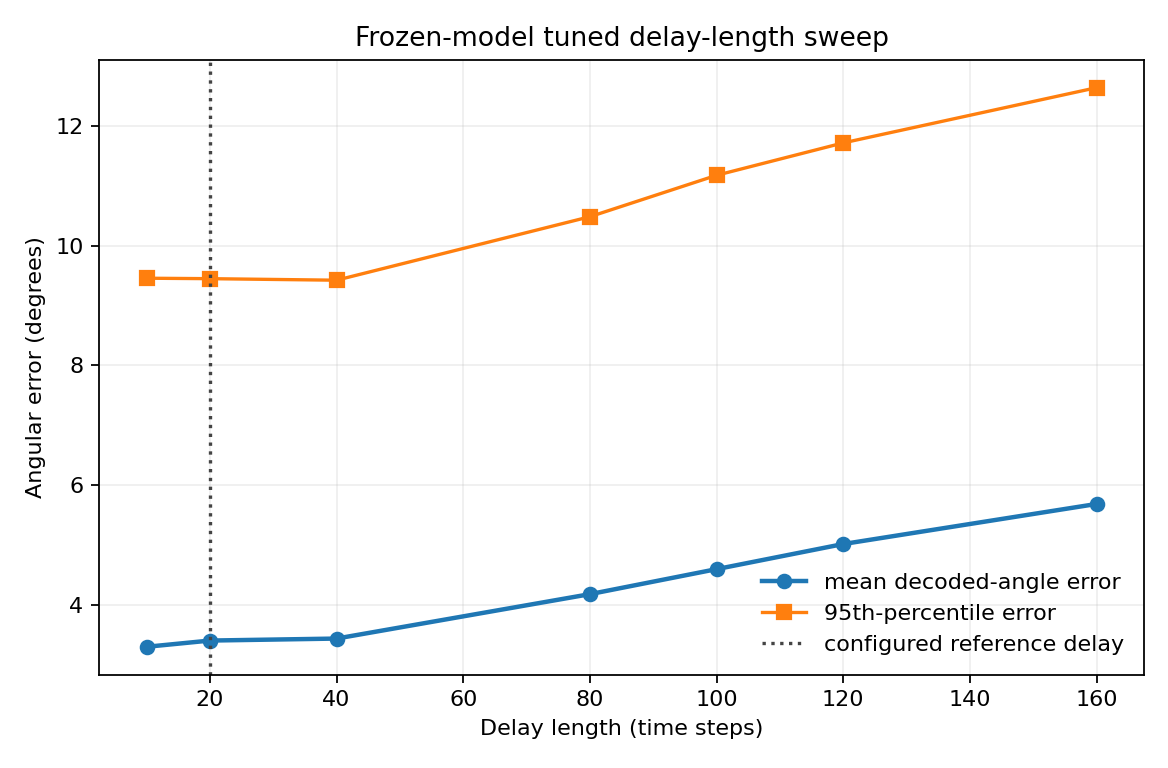

In [6]:
delay_csv = OUTPUT_DIR / "metrics" / f"{RUN_NAME}_delay_sweep.csv"
if delay_csv.exists():
    display(pd.read_csv(delay_csv))

delay_fig = OUTPUT_DIR / "figures" / f"{RUN_NAME}_delay_sweep.png"
if delay_fig.exists():
    display(Image(filename=str(delay_fig)))

## Hidden-State Memory Decoding

For this architecture, the circular output is deliberately silent before response. Delay-period memory should therefore be read from hidden-state decoding, not from the pre-response output population.

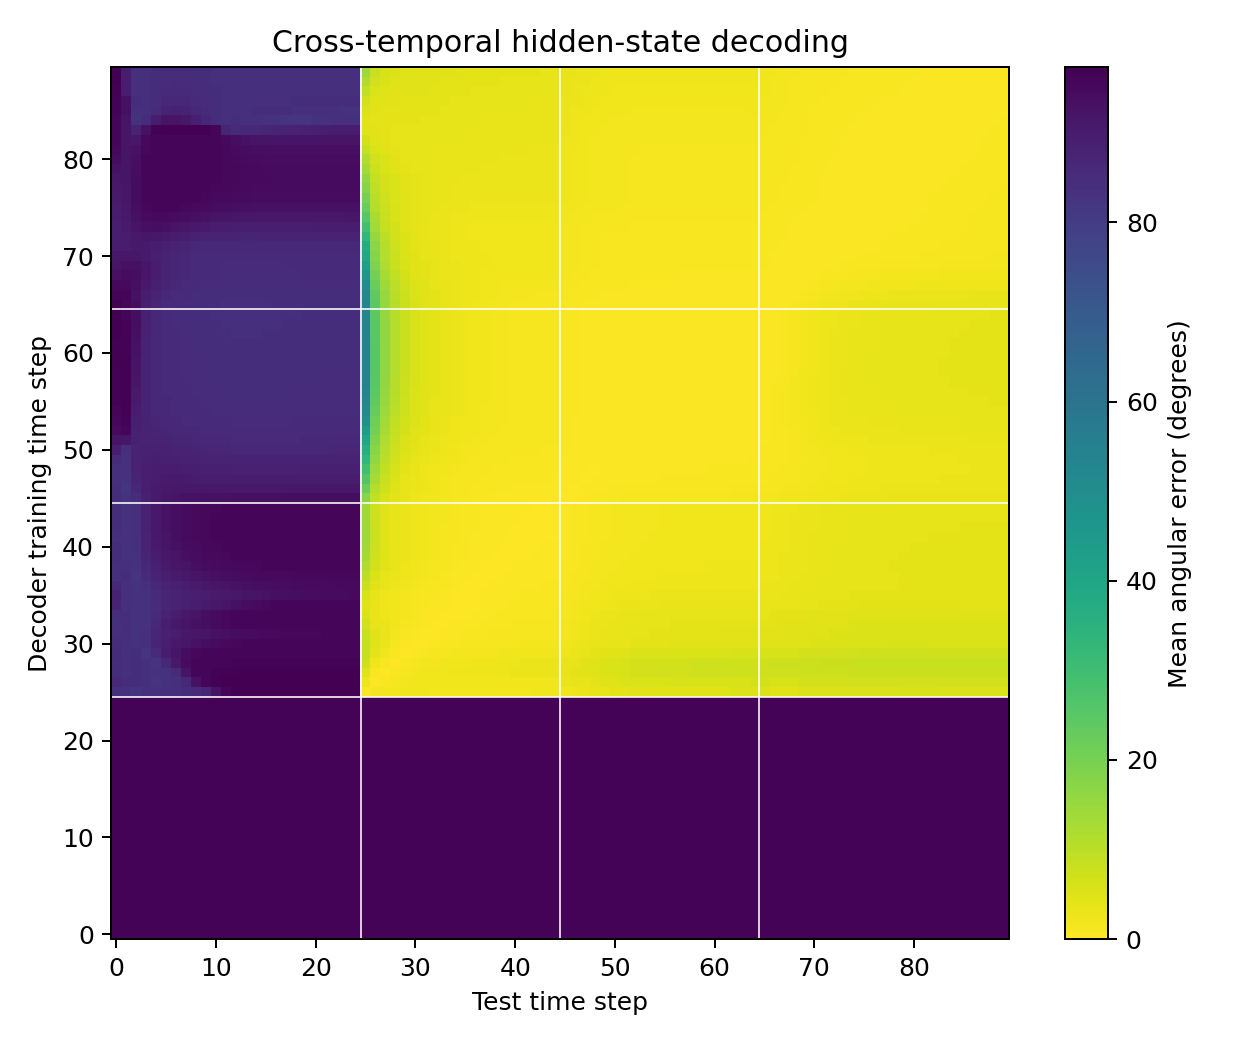

{'mean_diagonal_error_degrees': 27.082677087022198,
 'mean_delay_diagonal_error_degrees': 0.4274044632911682,
 'max_delay_diagonal_error_degrees': 0.4742248058319092}

In [7]:
decoder_fig = OUTPUT_DIR / "figures" / f"{RUN_NAME}_cross_temporal_decoder.png"
if decoder_fig.exists():
    display(Image(filename=str(decoder_fig)))

decoder_summary = summaries.get("decoder")
if decoder_summary:
    keys = [
        "mean_diagonal_error_degrees",
        "mean_delay_diagonal_error_degrees",
        "max_delay_diagonal_error_degrees",
    ]
    display({key: decoder_summary.get(key) for key in keys})

## Dynamics Figures

These cached figures summarize hidden-state trajectories, stability, sampled fixed-point/Jacobian analyses, and ring-manifold diagnostics.

In [ ]:
figure_names = [
    "pca_trajectories",
    "stability",
    "ring_manifold",
    "decoded_angle_over_time",
    "fixed_point_analysis",
    "fixed_point_landscape",
    "jacobian_spectrum",
    "perturbation_recovery",
]

for name in figure_names:
    path = OUTPUT_DIR / "figures" / f"{RUN_NAME}_{name}.png"
    if path.exists():
        print(name)
        display(Image(filename=str(path)))
    else:
        print("missing:", path)

## Optional Regeneration

These cells call the same package functions used by the command-line workflows. They are off by default to avoid overwriting cached artifacts during exploratory reading.

In [ ]:
if RUN_EVALUATION:
    from wm_rnn.evaluate import evaluate_model
    result = evaluate_model(cfg, CHECKPOINT)
    print(result.metrics_path)
    print(result.metrics)

if RUN_DELAY_SWEEP:
    from wm_rnn.delay_sweep import run_delay_sweep
    result = run_delay_sweep(cfg, CHECKPOINT, delays=[10, 20, 40, 80, 160])
    print(result.metrics_path)
    display(pd.DataFrame(result.results))

if RUN_PCA:
    from wm_rnn.analysis import run_pca_analysis
    result = run_pca_analysis(cfg, CHECKPOINT)
    print(result.summary_path)
    display(Image(filename=str(result.figure_path)))

if RUN_DECODER:
    from wm_rnn.cross_temporal_decoder import run_cross_temporal_decoder
    result = run_cross_temporal_decoder(cfg, CHECKPOINT)
    print(result.summary_path)
    display(Image(filename=str(result.figure_path)))

## PCA Ring Outline (matplotlib)

Scatter of **late-delay / perturbed start states** in PCA (before fixed-point
optimization), colored by source/target angle. These starts outline the ring
more evenly than post-optimization fixed points.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fp_arrays = OUTPUT_DIR / "arrays" / f"{RUN_NAME}_fixed_point_landscape.npz"
figure_path = OUTPUT_DIR / "figures" / f"{RUN_NAME}_pca_ring_outline.png"

if not fp_arrays.exists():
    raise FileNotFoundError(
        f"Missing {fp_arrays}. Generate fixed-point landscape analysis first."
    )

data = np.load(fp_arrays, allow_pickle=True)

# Pre-optimization start states outline the ring more evenly than
# post-optimization fixed points, which often collapse into clumps.
start_pc = np.asarray(data["start_pc"], dtype=float)
source_angles = np.asarray(data["source_angles"], dtype=float)
start_source = np.asarray(data["start_source"], dtype=object)

keep = np.isfinite(source_angles) & np.isin(
    start_source, ["late_delay", "perturbed_late_delay"]
)
pts = start_pc[keep]
angles = source_angles[keep]
angle_degrees = np.degrees(angles % (2.0 * np.pi))

fig, ax = plt.subplots(figsize=(8.5, 6.5))
scatter = ax.scatter(
    pts[:, 0],
    pts[:, 1],
    c=angle_degrees,
    cmap="hsv",
    vmin=0,
    vmax=360,
    s=14,
    alpha=0.85,
    linewidths=0,
)
ax.set_aspect("equal", adjustable="datalim")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Ring outline from late-delay start states")
ax.annotate(
    f"{len(pts)} late-delay/perturbed starts in PCA, colored by source angle",
    xy=(0.5, 1.02),
    xycoords="axes fraction",
    ha="center",
    va="bottom",
    fontsize=9,
)
cbar = fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("source angle (deg)")
fig.tight_layout()

figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
print(figure_path)
plt.show()


## Next Perturbation Notebooks

Keep perturbation-specific workflows separate once they become substantial. The next notebooks should be `02_gaussian_control.ipynb` for the generic control pack and `03_gain_modulation_experiment.ipynb` for the literature-grounded gain-modulation comparison.